In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df=pd.read_csv('retail_sales_dataset.csv')

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [25]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [27]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [28]:
df.shape

(1000, 9)

In [29]:
df = df.drop_duplicates()

In [30]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [31]:
df.fillna(df.mean(numeric_only=True),inplace=True)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [32]:
for col in df.select_dtypes(include='str'):
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [42]:
df["Gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [33]:
print("Variance:")
print(df.var(numeric_only=True))
print("Standard Deviation:")
print(df.std(numeric_only=True))
print("Covariance Matrix:")
cov=df.cov(numeric_only=True)
print(cov)
print("Correlation Matrix:")
corr = df.corr(numeric_only=True)
print(corr)

Variance:
Transaction ID     83416.666667
Age                  187.181518
Quantity               1.283087
Price per Unit     35979.016917
Total Amount      313597.347347
dtype: float64
Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64
Covariance Matrix:
                Transaction ID         Age    Quantity  Price per Unit  \
Transaction ID    83416.666667  257.599600   -8.709710    -3332.852853   
Age                 257.599600  187.181518   -0.367856      -99.711592   
Quantity             -8.709710   -0.367856    1.283087        3.760300   
Price per Unit    -3332.852853  -99.711592    3.760300    35979.016917   
Total Amount     -12135.915916 -464.046046  237.053053    90492.402402   

                 Total Amount  
Transaction ID  -12135.915916  
Age               -464.046046  
Quantity           237.053053  
Price per Unit   90492.402402  
Total Amoun

In [34]:
#Normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
columns_to_normalize = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
print(df.head())

   Transaction ID        Date Customer ID  Gender       Age Product Category  \
0               1  2023-11-24     CUST001    Male  0.347826           Beauty   
1               2  2023-02-27     CUST002  Female  0.173913         Clothing   
2               3  2023-01-13     CUST003    Male  0.695652      Electronics   
3               4  2023-05-21     CUST004    Male  0.413043         Clothing   
4               5  2023-05-06     CUST005    Male  0.260870           Beauty   

   Quantity  Price per Unit  Total Amount  
0  0.666667        0.052632      0.063291  
1  0.333333        1.000000      0.493671  
2  0.000000        0.010526      0.002532  
3  0.000000        1.000000      0.240506  
4  0.333333        0.052632      0.037975  


In [35]:
#Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
print(df.head())

   Transaction ID        Date Customer ID  Gender       Age Product Category  \
0               1  2023-11-24     CUST001    Male -0.540565           Beauty   
1               2  2023-02-27     CUST002  Female -1.125592         Clothing   
2               3  2023-01-13     CUST003    Male  0.629489      Electronics   
3               4  2023-05-21     CUST004    Male -0.321180         Clothing   
4               5  2023-05-06     CUST005    Male -0.833078           Beauty   

   Quantity  Price per Unit  Total Amount  
0  0.429265       -0.685123     -0.546704  
1 -0.453996        1.688464      0.971919  
2 -1.337258       -0.790615     -0.761098  
3 -1.337258        1.688464      0.078611  
4 -0.453996       -0.685123     -0.636035  


In [36]:
#Discretization
df["Sales_Levels"] = pd.cut(df["Total Amount"], bins=3, labels=["Low", "Medium", "High"])
print(df[["Total Amount", "Sales_Levels"]].head())

   Total Amount Sales_Levels
0     -0.546704          Low
1      0.971919       Medium
2     -0.761098          Low
3      0.078611          Low
4     -0.636035          Low


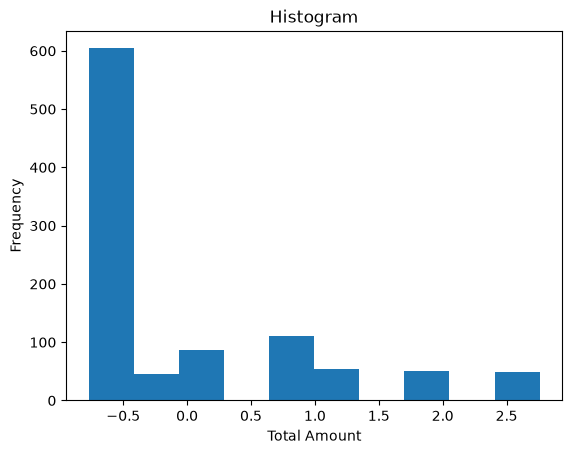

In [37]:
plt.hist(df["Total Amount"], bins=10)
plt.title("Histogram")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

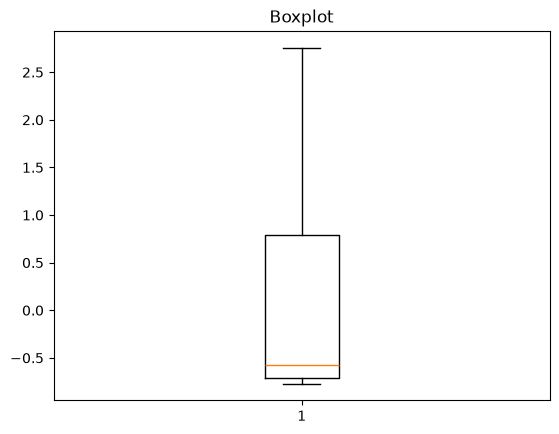

In [38]:
plt.boxplot(df["Total Amount"])
plt.title("Boxplot")
plt.show()

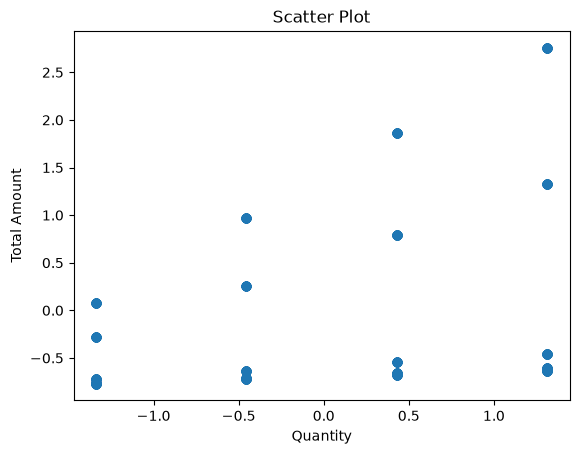

In [39]:
plt.scatter(df["Quantity"], df["Total Amount"])
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.title("Scatter Plot")
plt.show()

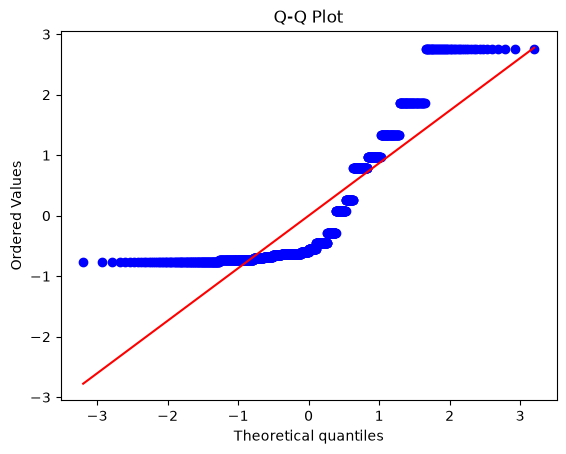

In [40]:
from scipy import stats

stats.probplot(df["Total Amount"], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

<Axes: >

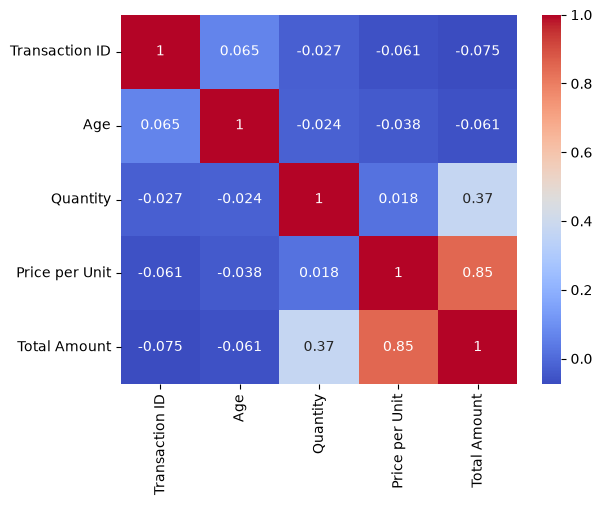

In [44]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm")

<Axes: xlabel='Gender', ylabel='count'>

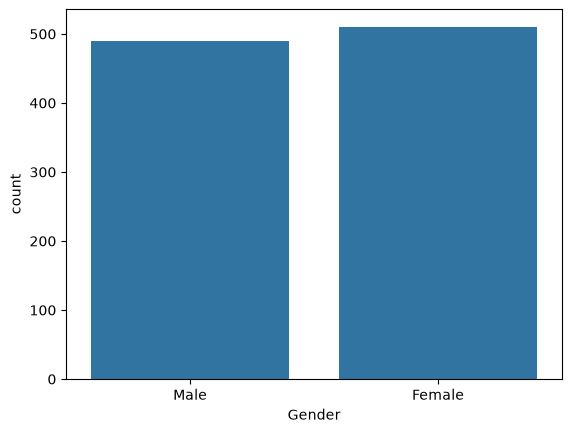

In [45]:
sns.countplot(x="Gender",data=df)

In [51]:
Q1 = df["Total Amount"].quantile(0.25)
Q3 = df["Total Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["Total Amount"] < lower) | (df["Total Amount"] > upper)]
    
print("Outliers:",outliers)
df_clean = df[(df["Total Amount"] >= lower) & (df["Total Amount"] <= upper)]

print("Original Data:", len(df))
print("After Removing Outliers:", len(df_clean))

Outliers: Empty DataFrame
Columns: [Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, Total Amount, Sales_Levels]
Index: []
Original Data: 1000
After Removing Outliers: 1000


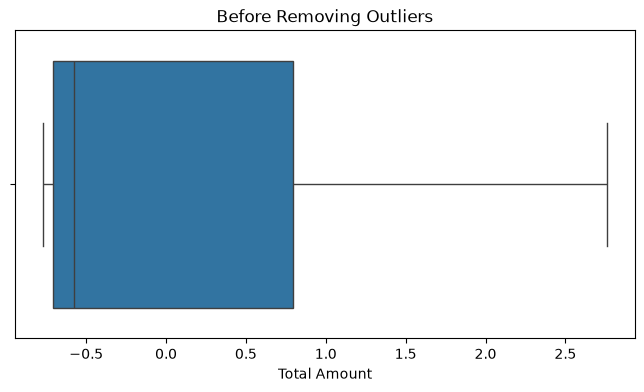

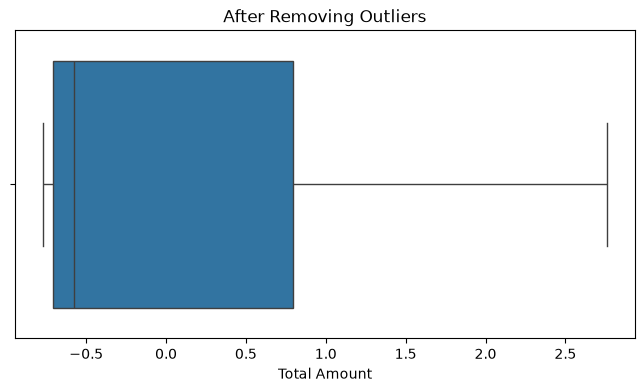

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Total Amount"])
plt.title("Before Removing Outliers")
plt.show()


plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["Total Amount"])
plt.title("After Removing Outliers")
plt.show()